<div class='bar_title'></div>

*Simulation for Decision Making (S4DM)*

# Output Analysis — Single Model

Summer Semester 26

Prof. Dr. Gunther Gust <br>
Chair for Enterprise AI <br>
Data Driven Decisions Group <br>
Center for Artificial Intelligence and Data Science (CAIDAS)

<img src="images/d3.png" style="width:20%; float:left;" />

<img src="images/CAIDASlogo.png" style="width:20%; float:left;" />

In [1]:
# Imports — run once
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# D3 colour palette
D3_BLUE   = '#1f77b4'
D3_ORANGE = '#ff7f0e'
D3_GREEN  = '#2ca02c'
D3_RED    = '#d62728'
D3_GRAY   = '#7f7f7f'

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[D3_BLUE, D3_ORANGE, D3_GREEN, D3_RED, D3_GRAY])

# Where we are

<img src="images/simulation_study_steps_output.png" style="width:80%; float:center;" />

**Last lecture — Verification & Validation (V&V)**: how do we know the model is correct, and that it represents the real system?

**This lecture**: once we trust the model — how do we turn one simulation run into a *defensible statement* about system performance?

## Motivation

You run your validated mensa simulation. The output:

> Average waiting time = **4.2 min**

Your colleague runs the same model with a different seed:

> Average waiting time = **5.1 min**

**Which one do you believe?** Neither — you need to characterize the uncertainty.

## The two core problems

| Problem | Where it bites |
|---|---|
| **Stochasticity** | Every run gives a different number — how precise is my point estimate? |
| **Autocorrelation** | Within one run, observations are not independent — naive confidence intervals lie |

Today's job: tools to handle both.

## Our running example — the mensa, again

Same model as in V&V. One counter, exponential arrivals, exponential service.

In [2]:
# --- Logger ---
class EventLogger:
    """Records every simulation event as a DataFrame row."""
    def __init__(self, verbose=False):
        self.events = []
        self.verbose = verbose
    def log(self, **kwargs):
        if self.verbose:
            print('  '.join(f'{k}={v}' for k, v in kwargs.items()))
        self.events.append(kwargs)
    def get_df(self):
        return pd.DataFrame(self.events)


# --- Resource class ---
class Mensa:
    def __init__(self, env, num_counters, mean_service):
        self.env = env
        self.counter = simpy.Resource(env, capacity=num_counters)
        self.mean_service = mean_service
    def serve(self):
        yield self.env.timeout(random.expovariate(1 / self.mean_service))


# --- Entity class ---
class Student:
    def __init__(self, env, name, mensa, logger):
        self.env, self.name, self.mensa, self.logger = env, name, mensa, logger
    def run(self):
        arrive = self.env.now
        self.logger.log(t=round(arrive, 2), name=self.name, event='arrives')
        with self.mensa.counter.request() as req:
            yield req
            wait = self.env.now - arrive
            self.logger.log(t=round(self.env.now, 2), name=self.name,
                            event='starts service', wait=round(wait, 2))
            yield self.env.process(self.mensa.serve())
            self.logger.log(t=round(self.env.now, 2), name=self.name, event='leaves')


# --- Generator function ---
def student_generator(env, mensa, logger, mean_inter):
    i = 0
    while True:
        yield env.timeout(random.expovariate(1 / mean_inter))
        env.process(Student(env, f'S{i}', mensa, logger).run())
        i += 1


# --- Run block ---
def run_mensa(seed, mean_inter=2.0, mean_service=1.5, sim_time=240, verbose=False):
    random.seed(seed)
    env = simpy.Environment()
    mensa = Mensa(env, num_counters=1, mean_service=mean_service)
    logger = EventLogger(verbose=verbose)
    env.process(student_generator(env, mensa, logger, mean_inter))
    env.run(until=sim_time)
    return logger.get_df()


## The motivating observation: same model, different numbers

In [3]:
# Three runs, three different seeds, same model
for seed in [1, 2, 3]:
    df = run_mensa(seed=seed, sim_time=240)
    waits = df.loc[df['event'] == 'starts service', 'wait']
    print(f'Seed {seed}: mean wait = {waits.mean():.2f} min   (n = {len(waits)} customers)')


Seed 1: mean wait = 6.38 min   (n = 134 customers)
Seed 2: mean wait = 2.83 min   (n = 117 customers)
Seed 3: mean wait = 2.85 min   (n = 115 customers)


# Agenda

1. **Performance Measures** — what we estimate, and what data types we estimate it from
2. **Confidence Intervals** — derivation from scratch
3. **Terminating Simulations** — the easy case: across-replication independence
4. **Steady-State Simulations** — the hard case: warmup bias and autocorrelation
    - 4.1 Initialization bias and Welch's method
    - 4.2 The autocorrelation problem
    - 4.3 Replication method
    - 4.4 Batch means
5. **Closing** — decision cheat sheet and bridge to the next lecture

# Part 1 — Performance Measures

## What is output analysis?

We have a system performance measure $\theta$ — e.g. *mean waiting time*, *95th-percentile delay*, *expected throughput*.

The simulation gives us an **estimator** $\hat\theta$ for $\theta$.

**Two questions:**

1. **Point estimate**: what is $\hat\theta$?
2. **Precision**: how good is it? — quantified via standard error or a confidence interval.

## Two types of performance measures

Every simulation produces data in one of two fundamental shapes — and the shape determines how we compute the mean. In both cases we'll call the estimated mean $\bar Y$ (no special new symbol) — only the recipe differs.

## Two types — (1) discrete-time data

A sequence $Y_1, Y_2, \ldots, Y_n$ indexed by **event**. Each $Y_i$ is a value attached to the $i$-th occurrence of something (a customer, a job, a transaction). Time is implicit — we just count events.

**Example (mensa):** $Y_i = $ waiting time of the $i$-th customer. Every customer contributes exactly one number.

The performance measure is the **sample mean**:
$$\bar Y = \frac{1}{n}\sum_{i=1}^n Y_i \qquad (\text{e.g. average waiting time } W)$$

## Two types — (2) continuous-time data

A function $\{Y(t),\ 0 \le t \le T_E\}$ that has a value at *every* moment. Between events the value is constant; at events it jumps. Time is essential — long values matter more than short ones.

**Example (mensa):** $Y(t) = $ number of customers in the queue at time $t$. Jumps up at arrivals, down at service completions.

The performance measure is the **time average**:
$$\bar Y = \frac{1}{T_E}\int_0^{T_E} Y(t)\,dt \qquad (\text{e.g. average queue length } L_q)$$

## Mapping onto queueing metrics you already know

| Performance measure | Data type | How to compute |
|---|---|---|
| $W$, $W_q$ — mean time *per customer* | discrete-time | sum over customers / number of customers |
| $L$, $L_q$ — mean number *in the system* | continuous-time | integral over time / $T_E$ |
| Utilization $\rho$ — fraction of time busy | continuous-time | integral of busy-indicator / $T_E$ |

In both cases we want $E[\bar Y] = \theta$ (unbiased). Reality: dependence and warmup bias make $\bar Y$ **biased** unless we're careful — the rest of this lecture is about how to fix that.

## How is the time average actually computed?

The integral $\int_0^{T_E} Y(t)\,dt$ looks scary — but $Y(t)$ in a discrete-event simulation is always a **step function**. It only changes value at events (arrival, service completion, …) and is constant between them.

So the integral is a **sum of rectangles**: for each piecewise-constant segment, multiply the value by its duration.

$$\int_0^{T_E} Y(t)\,dt \;=\; \sum_{k=1}^{K} Y_k \cdot \Delta t_k$$

where $Y_k$ is the value during the $k$-th segment and $\Delta t_k$ is the segment's length.

## Time average — tiny worked example

A counter with the following queue-length trace over 10 minutes:

| time interval | $\Delta t_k$ | queue length $Y_k$ | contribution $Y_k\!\cdot\!\Delta t_k$ |
|---|---|---|---|
| [0, 2)  | 2 min | 0 | 0 |
| [2, 5)  | 3 min | 1 | 3 |
| [5, 6)  | 1 min | 2 | 2 |
| [6, 10) | 4 min | 1 | 4 |

$$\bar Y \;=\; \frac{0 + 3 + 2 + 4}{10} \;=\; \frac{9}{10} \;=\; 0.9 \text{ customers (time-averaged)}$$

# 🧠 Mentimeter — your turn (Q1)

➡️ Open the Mentimeter and answer the question on screen.

# Part 2 — Confidence Intervals

*You have been using this formula since Lecture 0 — now we finally derive it. The goal isn't a new tool, it's the foundation under one you already trust.*

## Step 0 — What we have and what we want

You've seen the $t$-CI from the very first lecture (`motivation.ipynb`), used it heavily in V&V, and even implemented it yourself in Exercise 5. So the *what* is familiar — the next seven steps are the *why*.

We have $n$ **independent and identically distributed (iid)** observations $Y_1, \ldots, Y_n$ drawn from a distribution with **unknown mean $\mu$** and unknown standard deviation $\sigma$. "iid" means: each $Y_i$ comes from the same distribution, and they don't influence each other. We want to estimate $\mu$ — *and* say how sure we are.

**Point estimator:** the sample mean
$$\bar Y = \frac{1}{n}\sum_{i=1}^n Y_i$$

**Goal:** an interval $[\bar Y - H,\ \bar Y + H]$ that contains the true value $\mu$ with probability $1-\alpha$ (e.g. 95%).

## Step 1 — Mean and variance of $\bar Y$  (rules)

Two basic rules for random variables $X_1, \ldots, X_n$ and constants $a_i$:

**Linearity of expectation** — *the expectation of a sum is the sum of the expectations; constants pull out:*

$$E\!\left[\sum_i a_i X_i\right] = \sum_i a_i\, E[X_i] \qquad \text{(always — no independence needed)}$$

**Variance of a linear combination** (assuming the $X_i$ are **independent**) — *the variance of a sum is the sum of the variances; constants pull out squared:*

$$\mathrm{Var}\!\left(\sum_i a_i X_i\right) = \sum_i a_i^2\, \mathrm{Var}(X_i)$$

## Step 1 — Apply to $\bar Y$

Apply both rules to $\bar Y = \tfrac{1}{n}\sum Y_i$ with $a_i = 1/n$ and $E[Y_i] = \mu$, $\mathrm{Var}(Y_i) = \sigma^2$:

$$E[\bar Y] = \frac{1}{n}\sum_{i=1}^n E[Y_i] = \frac{1}{n}\cdot n\mu = \mu$$

$$\mathrm{Var}(\bar Y) = \sum_{i=1}^n \frac{1}{n^2}\,\mathrm{Var}(Y_i) = \frac{1}{n^2}\cdot n\sigma^2 = \frac{\sigma^2}{n}$$

→ $\bar Y$ is unbiased and has standard deviation $\sigma/\sqrt n$. The $\sqrt n$ in the denominator is why **more data = more precise estimator**.

## Step 2 — Distribution of $\bar Y$

Mean and variance are not enough — we need the *full distribution* to compute probabilities.

**Central Limit Theorem (CLT):** for reasonably large $n$, $\bar Y$ is approximately normal, regardless of the distribution of the individual $Y_i$:

$$\bar Y \;\approx\; \mathcal{N}\!\left(\mu,\ \frac{\sigma^2}{n}\right)$$

(If the $Y_i$ themselves happen to be normal, $\bar Y$ is exactly normal — no approximation needed.)

## Step 3 — Standardize

Subtract the mean, divide by the standard deviation → a standard normal $\mathcal{N}(0, 1)$:

$$Z \;=\; \frac{\bar Y - \mu}{\sigma/\sqrt n} \;\sim\; \mathcal{N}(0, 1)$$

Define $z_{\alpha/2}$ as the **upper $\alpha/2$ critical value** — the value such that $P(Z > z_{\alpha/2}) = \alpha/2$. By the **symmetry** of the normal distribution:

$$P\!\left(-z_{\alpha/2} \;\le\; Z \;\le\; z_{\alpha/2}\right) = 1 - \alpha$$

For $\alpha = 0.05$: $z_{0.025} \approx 1.96$ — the famous "1.96".

## Step 4 — Solve for $\mu$ (motivation)

The probability statement in Step 3 is *about* $Z$ — i.e. about a quantity that involves our data. But what we actually care about is **$\mu$**, the unknown population mean. We want a statement of the form *"$\mu$ lies between these two computable numbers with probability $1-\alpha$"*.

So we algebraically rearrange the inequality to isolate $\mu$ in the middle.

## Step 4 — Solve for $\mu$ (algebra)

Start from
$$P\!\left(-z_{\alpha/2} \le \frac{\bar Y - \mu}{\sigma/\sqrt n} \le z_{\alpha/2}\right) = 1 - \alpha.$$

Multiply through by $\sigma/\sqrt n$:
$$P\!\left(-z_{\alpha/2}\cdot\tfrac{\sigma}{\sqrt n} \le \bar Y - \mu \le z_{\alpha/2}\cdot\tfrac{\sigma}{\sqrt n}\right) = 1 - \alpha.$$

Rearrange for $\mu$ (signs flip, order reverses):
$$P\!\left(\bar Y - z_{\alpha/2}\cdot\tfrac{\sigma}{\sqrt n} \;\le\; \mu \;\le\; \bar Y + z_{\alpha/2}\cdot\tfrac{\sigma}{\sqrt n}\right) = 1 - \alpha.$$

That is already the CI formula — **if $\sigma$ were known**:
$$\bar Y \pm z_{\alpha/2}\cdot\frac{\sigma}{\sqrt n}.$$

## Step 5 — $\sigma$ is unknown → switch to the $t$-distribution

In practice we don't know $\sigma$; we estimate it from the same data:

$$S^2 = \frac{1}{n-1}\sum_{i=1}^n (Y_i - \bar Y)^2.$$

When we plug $S$ in place of $\sigma$, the standardized statistic is no longer standard normal — because $S$ itself is a noisy estimate. Gosset (1908, "Student") showed:

$$T \;=\; \frac{\bar Y - \mu}{S/\sqrt n} \;\sim\; t_{n-1}$$

a **$t$-distribution with $n-1$ degrees of freedom**. It is also symmetric, but has **heavier tails** than the standard normal — paying for the uncertainty in $S$. So $t_{\alpha/2,\,n-1} > z_{\alpha/2}$, and the CI is correspondingly wider. As $n$ grows, $t \to z$; for $n \ge 30$ the difference is already negligible.

## Step 6 — Final formula

Repeat the rearrangement from Step 4, but with $T$ and $t_{\alpha/2,\,n-1}$ in place of $Z$ and $z_{\alpha/2}$ (same symmetry argument):

$$\boxed{\;\bar Y \;\pm\; t_{\alpha/2,\,n-1}\cdot\frac{S}{\sqrt n}\;}$$

The half-width $H = t_{\alpha/2,\,n-1}\cdot S/\sqrt n$ is what we want to be small.

## Step 7 — What the CI actually means (before/after)

**Before observing the data:** the interval $[\bar Y - H,\ \bar Y + H]$ is a *random* quantity (because $\bar Y$ and $S$ are random). The statement *"the interval contains $\mu$"* has probability $1 - \alpha$.

**After observing the data:** the bounds are fixed numbers. $\mu$ is also a fixed (but unknown) number. Either $\mu$ is in the interval or it isn't — no probability any more.

## Step 7 — Frequentist interpretation + Catch

**Correct frequentist interpretation:** if I repeat the experiment many times, *about $(1-\alpha)\cdot 100\%$ of the constructed intervals will contain the true $\mu$*.

**Catch:** the whole construction relies on the $Y_i$ being **independent**. Inside a single simulation run they almost never are — and the rest of this lecture is about how to get around that.

# 🧠 Mentimeter — your turn (Q2 + Q3)

➡️ Open the Mentimeter and answer the two questions on screen.

# Agenda

1. **Performance Measures** — what we estimate, and what data types we estimate it from
2. **Confidence Intervals** — derivation from scratch
3. **Terminating Simulations** — the easy case: across-replication independence
4. **Steady-State Simulations** — the hard case: warmup bias and autocorrelation
    - 4.1 Initialization bias and Welch's method
    - 4.2 The autocorrelation problem
    - 4.3 Replication method
    - 4.4 Batch means
5. **Closing** — decision cheat sheet and bridge to the next lecture

## Two types of simulation

| | **Terminating** | **Steady-state (non-terminating)** |
|---|---|---|
| Stops when | a natural event ends the run | (does not stop — we choose when) |
| Initial conditions | matter, are part of the model | are an *artifact* we want to forget |
| Goal | characterize the whole run, *including* startup | characterize long-run behavior, *independent* of startup |
| Mensa example | "lunch rush: 11:30–13:30" | "long-run average wait at a permanently open canteen" |
| Other examples | bank open 8:30–16:30; produce 100 parts | emergency room, internet routers, assembly lines |

The choice is **part of the modeling decision**, not a technicality.


# Part 3 — Terminating Simulations

*The easy case — because independence is given.*

## The key insight: across-replication data is iid

One simulation run (replication) uses one RNG stream.

- **Within** a replication: observations are autocorrelated (one customer's wait depends on the previous one's).
- **Across** replications: each replication uses a *different seed* → **independent**.

→ If we summarize each replication into one number $\bar Y_r$, the $\bar Y_1, \ldots, \bar Y_R$ are iid.

→ Standard $t$-CI applies directly. 🎉

## Nomenclature — replication method

For $R$ independent replications:

**Per-replication mean:** $\bar Y_r = \frac{1}{n_r}\sum_{i=1}^{n_r} Y_{r,i}$

**Across-replication mean:** $\bar Y_{\cdot\cdot} = \frac{1}{R}\sum_{r=1}^R \bar Y_r$

**Across-replication variance:** $S^2 = \frac{1}{R-1}\sum_{r=1}^R (\bar Y_r - \bar Y_{\cdot\cdot})^2$

**Confidence interval:**
$$\bar Y_{\cdot\cdot} \pm t_{\alpha/2,\,R-1}\cdot\frac{S}{\sqrt R}$$

The variance estimator $S^2$ is **unbiased** because the $\bar Y_r$ are iid.

## Nomenclature — Mensa example

We simulate $R = 3$ lunch-shift replications, each with a different seed. In replication $r$, customer $i$ waits $Y_{r,i}$ minutes.

| Replication $r$ | Customer waits $Y_{r,i}$ (min) | $n_r$ | Per-replication mean $\bar Y_r$ |
|---|---|---|---|
| 1 | 0.0, 2.1, 5.4, 3.8, 1.9, … | 118 | 3.42 |
| 2 | 1.2, 0.0, 4.7, 6.1, 2.3, … | 122 | 4.10 |
| 3 | 0.5, 1.8, 2.9, 3.3, 0.0, … | 115 | 2.85 |

Then
$$\bar Y_{\cdot\cdot} = \frac{3.42 + 4.10 + 2.85}{3} = 3.46 \text{ min}, \qquad S^2 = \frac{1}{2}\sum_{r=1}^3 (\bar Y_r - 3.46)^2.$$

→ The $Y_{r,i}$ (per-customer waits) are autocorrelated within a replication, but the *summaries* $\bar Y_1, \bar Y_2, \bar Y_3$ are independent — which is why the CI formula above works.

## Mensa: 10 replications of a 4-hour lunch shift

In [4]:
def lunch_shift_mean_wait(seed, sim_time=240):
    df = run_mensa(seed=seed, sim_time=sim_time)
    waits = df.loc[df['event'] == 'starts service', 'wait']
    return waits.mean()

R = 10
rep_means = np.array([lunch_shift_mean_wait(seed=s) for s in range(1, R+1)])

mean = rep_means.mean()
S = rep_means.std(ddof=1)
t_crit = stats.t.ppf(0.975, df=R-1)
H = t_crit * S / np.sqrt(R)

print(f'R = {R} replications')
print(f'Per-replication means: {np.round(rep_means, 2)}')
print(f'Point estimate:  {mean:.2f} min')
print(f'95% CI:          [{mean-H:.2f}, {mean+H:.2f}]   (half-width H = {H:.2f})')


R = 10 replications
Per-replication means: [6.38 2.83 2.85 3.89 1.16 1.83 1.11 3.82 8.71 2.03]
Point estimate:  3.46 min
95% CI:          [1.73, 5.19]   (half-width H = 1.73)


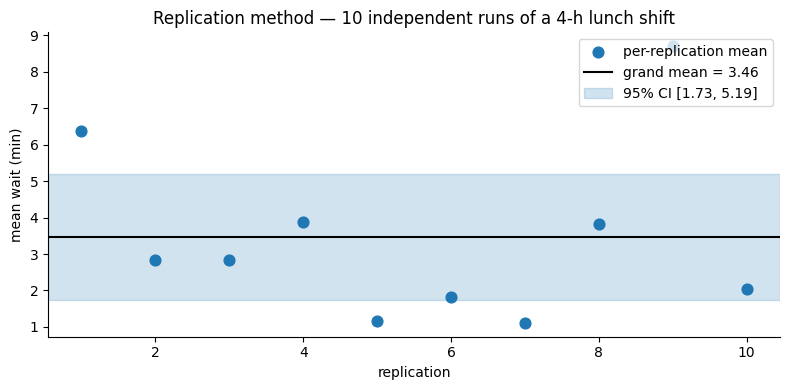

In [5]:
# Visualize: each replication is a dot, CI as a band around the grand mean
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(range(1, R+1), rep_means, s=60, color=D3_BLUE, zorder=3, label='per-replication mean')
ax.axhline(mean, color='black', lw=1.5, label=f'grand mean = {mean:.2f}')
ax.axhspan(mean-H, mean+H, alpha=0.2, color=D3_BLUE, label=f'95% CI [{mean-H:.2f}, {mean+H:.2f}]')
ax.set_xlabel('replication')
ax.set_ylabel('mean wait (min)')
ax.set_title('Replication method — 10 independent runs of a 4-h lunch shift')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Sample size for a target precision

**Real-world purpose:** before committing days of compute or signing off on a number, you want to know *up front* how many replications buy you a CI tight enough to back the decision (e.g. "I need to know the average wait with a precision of ± 0.3 min") — instead of running blindly and hoping.

**Goal:** half-width $H \le \varepsilon$ with confidence $1-\alpha$.

From the CI formula, solving for $R$ (using $z$ approximation for $t$):

$$R \ge \left(\frac{z_{\alpha/2}\cdot s_0}{\varepsilon}\right)^2$$

where $s_0$ is the sample standard deviation from a **pilot run** of $R_0$ replications.

## Recall from V&V — similar formula, different question

In V&V we asked: *how many runs do I need to detect a **difference $\delta$ between the simulation and the real system** with power $1-\beta$?* The answer was
$$n \approx \frac{2 s_0^2 (z_{\alpha/2} + z_{\beta})^2}{\delta^2}.$$

In output analysis the question is narrower — there is no real-system comparison, only my own estimate: *how many runs so my CI is at most $\varepsilon$ wide?*
$$R \ge \left(\frac{z_{\alpha/2}\cdot s_0}{\varepsilon}\right)^2.$$

In both formulas $s_0$ is the same thing: the sample standard deviation estimated from a **pilot run**.

**Same machinery, simpler shape** — pilot to estimate $s_0$, then plug in the target. The V&V version is the two-sample / two-error generalization (it has to control both Type I and Type II errors against a reference $\mu_0$); here we only care about the half-width of one CI, so $\beta$ drops out and we get the simpler form.

→ The workflow you learned in V&V transfers directly.

## Sample size in practice

In [6]:
# Pilot: R0 = 5 replications already done
R0 = 5
pilot = rep_means[:R0]
s0 = pilot.std(ddof=1)

# Target: half-width <= 0.3 min, 95% confidence
eps = 0.3
alpha = 0.05
z = stats.norm.ppf(1 - alpha/2)

R_required = int(np.ceil((z * s0 / eps)**2))

print(f'Pilot: R0 = {R0}, pilot s0 = {s0:.3f} min')
print(f'Target: half-width <= {eps} min at {(1-alpha)*100:.0f}% confidence')
print(f'Required: R >= {R_required} replications')
print(f'Need to collect {max(0, R_required - R0)} additional replications.')

Pilot: R0 = 5, pilot s0 = 1.925 min
Target: half-width <= 0.3 min at 95% confidence
Required: R >= 159 replications
Need to collect 154 additional replications.


## Quantile estimation

Sometimes the *mean* is not the right answer. Service-level agreements care about tails:

> "95% of customers wait less than $q$ minutes."

**Point estimator for the $p$-quantile $q_p$:**

1. Pool waits from all $R$ replications, sort them: $Y_{(1)} \le Y_{(2)} \le \ldots \le Y_{(N)}$.
2. $\hat q_p = Y_{(\lceil Np\rceil)}$.

**Confidence interval** via order statistics (normal approximation):
$$l = \lfloor Np - z_{\alpha/2}\sqrt{Np(1-p)}\rfloor, \quad u = \lceil Np + z_{\alpha/2}\sqrt{Np(1-p)}\rceil$$

CI = $[Y_{(l)},\,Y_{(u)}]$.

*The derivation of this formula — and why it works for **any** underlying distribution — is in Appendix A.4.*

In [7]:
# Pool waits from all 10 replications
all_waits = []
for s in range(1, R+1):
    df = run_mensa(seed=s, sim_time=240)
    all_waits.extend(df.loc[df['event'] == 'starts service', 'wait'].tolist())
all_waits = np.sort(all_waits)
N = len(all_waits)

p = 0.95
q_hat = all_waits[int(np.ceil(N*p)) - 1]

z = stats.norm.ppf(1 - 0.05/2)
l = int(np.floor(N*p - z*np.sqrt(N*p*(1-p)))) - 1
u = int(np.ceil(N*p + z*np.sqrt(N*p*(1-p)))) - 1

print(f'N = {N} pooled waits')
print(f'95th-percentile point estimate: {q_hat:.2f} min   (at order stat {int(np.ceil(N*p))})')
print(f'CI bounds via order statistics: l = {l+1}, u = {u+1}   (1-indexed)')
print(f'95% CI for the 95th percentile: [Y_({l+1}), Y_({u+1})] = [{all_waits[l]:.2f}, {all_waits[u]:.2f}] min')

N = 1156 pooled waits
95th-percentile point estimate: 14.06 min   (at order stat 1099)
CI bounds via order statistics: l = 1083, u = 1113   (1-indexed)
95% CI for the 95th percentile: [Y_(1083), Y_(1113)] = [12.92, 15.79] min


# Part 4 — Steady-State Simulations

## Why this case is hard

In **Part 3** the math was easy because each replication ended at a well-defined natural event (the lunch shift ended, the bank closed). One replication → one iid summary $\bar Y_r$ → the standard $t$-CI applies directly.

In a **steady-state** problem, that recipe breaks down for three independent reasons:

| Obstacle | Consequence |
|---|---|
| **No natural endpoint** | The run length $T_E$ becomes a *choice*. Stop too early and you haven't seen steady state; stop too late and you waste compute. |
| **Initial conditions are an artifact** | The system starts in some chosen state (e.g. empty mensa). The first observations are *systematically* biased by that choice — but we want long-run behavior, *independent* of how we started. |
| **Within-run observations are autocorrelated** | Customer $i+1$'s wait is highly related to customer $i$'s. So the naive variance estimator $S^2/n$ is biased low → naive CIs are too narrow → **false confidence**. |


The next sections fix each problem in turn:

- **4.1 Warmup deletion** (Welch's method) — handles the initialization bias
- **4.2 The autocorrelation problem** — quantifies and demonstrates the variance underestimation
- **4.3 Replication method** — extends Part 3 by deleting warmup from each of $R$ runs
- **4.4 Batch means** — turns *one* long run into $k$ approximately-independent batches

## The setting

In a steady-state context, $\theta$ specifically denotes the **long-run value of the performance measure** — the value it would converge to if we could simulate forever, independent of how we started:

$$\theta \;=\; \lim_{n\to\infty}\frac{1}{n}\sum_{i=1}^n E[Y_i]$$

But:
- We can't simulate to infinity.
- The first observations are biased by the (arbitrary) initial state.
- Within one run, the $Y_i$ are autocorrelated → standard CI formulas don't apply.

We tackle these **one at a time**.

## 4.1 — Initialization bias (warmup)

The mensa starts **empty and idle**. The first 20 customers walk into an empty queue → their waits are systematically too low. This biases any "average wait" computed over the full run.

Two cures:
1. **Intelligent initialization** — start the system in a state resembling steady state (hard).
2. **Warmup deletion** — split the run into $[0, T_0]$ *warmup* (discarded) and $[T_0, T_E]$ *data collection*.

The question becomes: **how large should $T_0$ be?**

## See the warmup: a single long mensa run

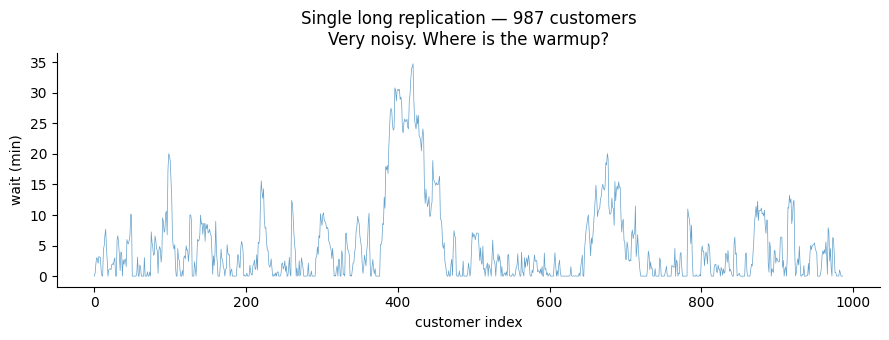

In [8]:
# One long run, plot wait by customer index
df = run_mensa(seed=42, sim_time=2000)
waits = df.loc[df['event'] == 'starts service', 'wait'].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(waits.index, waits.values, lw=0.5, color=D3_BLUE, alpha=0.7)
ax.set_xlabel('customer index')
ax.set_ylabel('wait (min)')
ax.set_title(f'Single long replication — {len(waits)} customers\nVery noisy. Where is the warmup?')
plt.tight_layout()
plt.show()

## Welch's method — find $T_0$ more objectively

**4-step recipe:**

1. Run **$R$ replications**, each with the same initial conditions, different seeds. Call $Y_{r,i}$ the $i$-th observation in replication $r$.
2. Form the **ensemble average** across replications:
$$\bar Y_{\cdot i} = \frac{1}{R}\sum_{r=1}^R Y_{r,i}$$
3. Smooth with a **moving average** of window $w$:
$$\bar Y_{\cdot i}(w) = \frac{1}{2w+1}\sum_{s=-w}^{w}\bar Y_{\cdot,\,i+s}$$
4. **Plot** $\bar Y_{\cdot i}(w)$ vs $i$. Choose $T_0$ where the curve flattens into a plateau.

**Why double smoothing?** Ensemble removes stochasticity *across* replications; moving average removes stochasticity *over time*. Together they expose the systematic warmup trend.

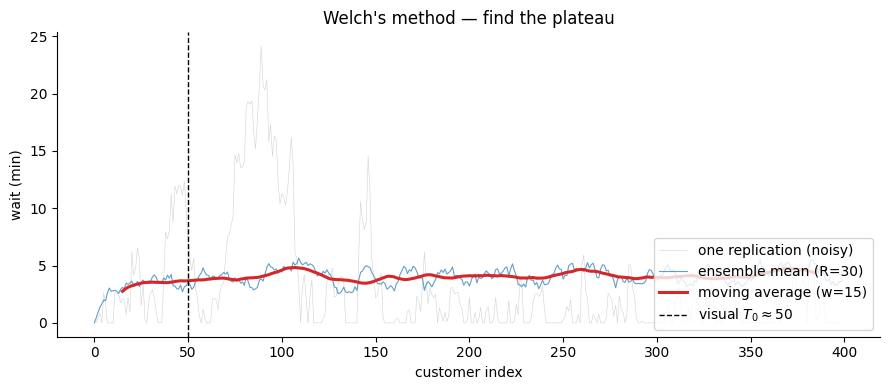

In [9]:
# Welch's method on the mensa
R_welch = 30
n_obs = 400   # first 400 customers per replication

ensemble = []
for s in range(1, R_welch + 1):
    df = run_mensa(seed=s, sim_time=2000)
    w = df.loc[df['event'] == 'starts service', 'wait'].values
    if len(w) >= n_obs:
        ensemble.append(w[:n_obs])
ensemble = np.array(ensemble)
ens_mean = ensemble.mean(axis=0)

# Moving average with window w_ma
def moving_average(x, w):
    out = np.full_like(x, np.nan, dtype=float)
    for i in range(w, len(x) - w):
        out[i] = x[i-w:i+w+1].mean()
    return out

w_ma = 15
smoothed = moving_average(ens_mean, w_ma)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ensemble[0], lw=0.4, color='lightgray', label='one replication (noisy)')
ax.plot(ens_mean, lw=0.8, color=D3_BLUE, alpha=0.7,
        label=f'ensemble mean (R={R_welch})')
ax.plot(smoothed, lw=2.2, color=D3_RED,
        label=f'moving average (w={w_ma})')
ax.axvline(50, color='black', ls='--', lw=1, label='visual $T_0 \\approx 50$')
ax.set_xlabel('customer index')
ax.set_ylabel('wait (min)')
ax.set_title("Welch's method — find the plateau")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Caveat: the last step is visual

Welch's method removes the stochasticity but the *judgment* of where the plateau begins stays with you.

- **Honest practice**: report the chosen $T_0$ alongside the plot.
- **Rule of thumb**: when in doubt, choose $T_0$ **too large** rather than too small.

# 🧠 Mentimeter — your turn (Q4)

➡️ Open the Mentimeter and answer the question on screen.

## 4.2 — The autocorrelation problem

Even after deleting warmup, the within-replication observations $Y_1, Y_2, \ldots$ are **not independent**.

The naive variance estimator $S^2/n$ is then a **biased** estimator of $\mathrm{Var}(\bar Y)$, and any CI built on it is wrong.

## Why it matters — the general variance rule

For a sum of two random variables (not necessarily independent), the standard variance rule is:

$$\mathrm{Var}(X + Y) \;=\; \mathrm{Var}(X) + \mathrm{Var}(Y) + 2\,\mathrm{Cov}(X, Y)$$

Generalized to $n$ random variables, this becomes a double sum over all pairs:

$$\mathrm{Var}\!\left(\sum_i X_i\right) \;=\; \sum_{i=1}^n\sum_{j=1}^n \mathrm{Cov}(X_i, X_j)$$

When the $X_i$ are independent, the off-diagonal $\mathrm{Cov}$ terms vanish and we recover the Step-1 formula $\mathrm{Var}(\bar Y) = \sigma^2/n$. When they are not, those off-diagonals stay — and they accumulate into a correction factor.

## Applied to $\bar Y$ with autocorrelated $Y_i$

Define (assuming covariance-stationary post-warmup output)
$$\gamma_k = \mathrm{Cov}(Y_i, Y_{i+k}),\qquad \rho_k = \gamma_k/\gamma_0$$

Plug $a_i = 1/n$ into the double sum and group terms by lag $k = |i-j|$ (full derivation in Appendix A.1):

$$\mathrm{Var}(\bar Y) = \frac{\sigma^2}{n}\left[1 + 2\sum_{k=1}^{n-1}\left(1-\frac{k}{n}\right)\rho_k\right]$$

The bracket is a **correction factor** — the price for the off-diagonal covariances:
- $\rho_k \approx 0$ (independent) → factor = 1 → naive Step-1 formula works.
- $\rho_k > 0$ (positive autocorr.) → factor > 1 → $\mathrm{Var}(\bar Y)$ is **larger** than naive $\sigma^2/n$ → naive CIs are **too narrow** (overconfident!).
- $\rho_k < 0$ → factor < 1 → naive CIs are too wide.

In queueing systems, waits are **almost always positively autocorrelated** (a long queue today implies long waits tomorrow).

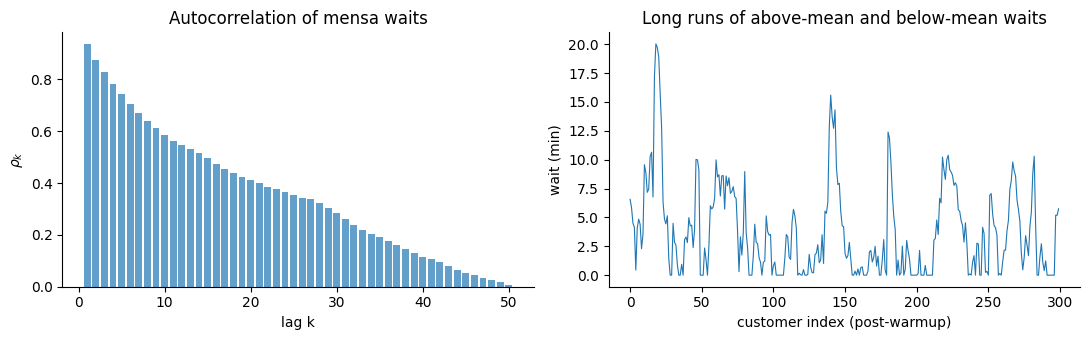

In [10]:
# Show the autocorrelation in mensa waits
df = run_mensa(seed=42, sim_time=4000)
waits = df.loc[df['event'] == 'starts service', 'wait'].reset_index(drop=True)
waits_post_warmup = waits.iloc[80:].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# ACF
max_lag = 50
acf = [waits_post_warmup.autocorr(lag=k) for k in range(1, max_lag+1)]
axes[0].bar(range(1, max_lag+1), acf, color=D3_BLUE, alpha=0.7)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_xlabel('lag k')
axes[0].set_ylabel(r'$\rho_k$')
axes[0].set_title('Autocorrelation of mensa waits')

# Time series snippet
axes[1].plot(waits_post_warmup.iloc[:300].values, lw=0.8, color=D3_BLUE)
axes[1].set_xlabel('customer index (post-warmup)')
axes[1].set_ylabel('wait (min)')
axes[1].set_title('Long runs of above-mean and below-mean waits')

plt.tight_layout()
plt.show()

## Concrete demo of the bias

Compare:
1. **Naive CI** on within-replication waits (treating them as iid — wrong)
2. **Honest CI** from $R$ independent replications (correct)

In [11]:
# Naive CI from a single long run
single_waits = waits_post_warmup.values
naive_mean = single_waits.mean()
naive_S = single_waits.std(ddof=1)
naive_n = len(single_waits)
naive_H = stats.t.ppf(0.975, naive_n - 1) * naive_S / np.sqrt(naive_n)

# Honest CI from replications (each summarized to one mean)
R_h = 20
rep_means_long = []
for s in range(1, R_h + 1):
    df_r = run_mensa(seed=s, sim_time=4000)
    w = df_r.loc[df_r['event'] == 'starts service', 'wait'].iloc[80:]
    rep_means_long.append(w.mean())
rep_means_long = np.array(rep_means_long)
hon_mean = rep_means_long.mean()
hon_S = rep_means_long.std(ddof=1)
hon_H = stats.t.ppf(0.975, R_h - 1) * hon_S / np.sqrt(R_h)

print(f'Naive  CI (single run, n={naive_n}):  {naive_mean:.2f} +/- {naive_H:.3f}   (half-width {naive_H:.3f})')
print(f'Honest CI (R={R_h} replications):    {hon_mean:.2f} +/- {hon_H:.3f}   (half-width {hon_H:.3f})')
print(f'\nThe naive half-width is ~{hon_H/naive_H:.1f}x too small → false confidence!')


Naive  CI (single run, n=1867):  4.21 +/- 0.255   (half-width 0.255)
Honest CI (R=20 replications):    4.61 +/- 0.469   (half-width 0.469)

The naive half-width is ~1.8x too small → false confidence!


# 🧠 Mentimeter — your turn (Q5)

➡️ Open the Mentimeter and answer the question on screen.

## 4.3 — The replication method

**Idea:** treat steady state like a terminating sim — many replications, delete warmup $T_0$ from each.

| Replication | Obs 1 | … | Obs $d$ | **Obs $d+1$** | … | **Obs $n$** | Replication mean |
|---|---|---|---|---|---|---|---|
| 1 | $Y_{1,1}$ | … | $Y_{1,d}$ | $Y_{1,d+1}$ | … | $Y_{1,n}$ | $\bar Y_1$ |
| 2 | $Y_{2,1}$ | … | $Y_{2,d}$ | $Y_{2,d+1}$ | … | $Y_{2,n}$ | $\bar Y_2$ |
| ⋮ | ⋮ | | ⋮ | ⋮ | | ⋮ | ⋮ |
| $R$ | $Y_{R,1}$ | … | $Y_{R,d}$ | $Y_{R,d+1}$ | … | $Y_{R,n}$ | $\bar Y_R$ |
| | ↑ *warmup — discarded* | | | ↑ *data-collection phase* | | | → $\bar Y_{\cdot\cdot}$ |

For replication $r$, average only over the post-warmup observations:
$$\bar Y_r = \frac{1}{n - d}\sum_{i=d+1}^n Y_{r,i}$$

Across replications: identical CI machinery as in Part 3.

## 4.3 — Pros, cons, and rules of thumb

**Pros / Cons**

| ✔ | ✘ |
|---|---|
| Re-uses our terminating-sim machinery | Warmup deleted $R$ times — wasteful |
| Across-replication independence is solid | Need a sensible $T_0$ first |

**Best-practice rules of thumb:**
- $T_E - T_0 \gtrsim 10\cdot T_0$
- $R \le 25$; if you have more compute, **extend $T_E$** rather than adding replications. Beyond $R \approx 25$ the $t$-quantile is already close to $z$, so further runs barely shrink the CI through that channel — whereas a longer $T_E$ buys *more precise per-replication estimates* at no extra warmup cost, which pays off through a smaller across-replication $S$.

## 4.4 — Batch means: one long run, partitioned

**Motivation:** the replication method wastes $R \cdot T_0$ on warmup. If $T_0$ is large, this hurts.

**Idea:** Make **one** long run. Delete warmup once. Partition the rest into $k$ **batches** of size $m$.

<img src="images/oa_batch_means.png" width="700">

If $m$ is large enough that batches are approximately independent → treat batch means as iid → standard CI.

## Batch means — formulas

After warmup deletion, $N$ observations remain. Partition into $k$ batches of size $m$ ($N = km$).

**Batch means:**
$$\bar Y_j = \frac{1}{m}\sum_{i=(j-1)m+1}^{jm} Y_i,\qquad j = 1, \ldots, k$$

**Grand mean:** $\bar Y_{\cdot\cdot} = \frac{1}{k}\sum_{j=1}^k \bar Y_j$

**Variance estimator:**
$$\widehat{\mathrm{Var}}(\bar Y_{\cdot\cdot}) = \frac{1}{k(k-1)}\sum_{j=1}^k (\bar Y_j - \bar Y_{\cdot\cdot})^2$$

**CI:**
$$\bar Y_{\cdot\cdot} \pm t_{\alpha/2,\,k-1}\cdot\sqrt{\widehat{\mathrm{Var}}(\bar Y_{\cdot\cdot})}$$

**Heuristic:** choose $k \in [10, 30]$ — enough degrees of freedom, batches big enough to be ~independent.

## How large should a batch be?  (setup + trade-off)

Recall: after warmup deletion we have $N$ observations, which we partition into $k$ batches of size $m$ (so $N = k \cdot m$).
- $k$ = **number of batches** (rows in the batch-means computation)
- $m$ = **batch size** (observations per batch)

Two opposing pressures on the choice of $m$:

| | Pro | Contra |
|---|---|---|
| **$m$ large** | Batch means ≈ independent → CI is honest | Few batches → few degrees of freedom → CI wider |
| **$m$ small** | Many batches → tighter $t$-quantile | Batch means still autocorrelated → CI lies |

The $k \in [10, 30]$ rule of thumb balances both — but only *implicitly*. The principled diagnostic is the **lag-1 autocorrelation of the batch means** $\bar Y_1, \ldots, \bar Y_k$: if the batches are large enough, consecutive batch means are approximately uncorrelated.

**Rule of thumb:** $|\rho_1^{\text{batch}}| < 0.2$ (some authors say $< 0.1$).

## Fishman's iterative procedure

1. Start with a large $k$ (many small batches), e.g. $k = 100$ → $m = N/100$.
2. Compute $\rho_1$ of the batch means $\bar Y_1, \ldots, \bar Y_k$.
3. If $|\rho_1| > 0.2$: **double the batch size $m$** (halve the number of batches $k$), go back to step 2.
4. If $|\rho_1| < 0.2$ **and** $k \ge 10$: done — these $(m, k)$ can be used.
5. If $k$ drops below 10 before independence is reached: total post-warmup data $N$ is too small — simulate longer.

# 🧠 Mentimeter — your turn (Q6)

➡️ Open the Mentimeter and answer the question on screen.

In [12]:
# Batch means on a single long mensa run
df_long = run_mensa(seed=99, sim_time=80000)
waits_long = df_long.loc[df_long['event'] == 'starts service', 'wait'].reset_index(drop=True)
waits_long = waits_long.iloc[80:].values   # delete warmup

# Choose k = 20 batches
k = 20
m = len(waits_long) // k
truncated = waits_long[:k*m]
batches = truncated.reshape(k, m)
batch_means = batches.mean(axis=1)

grand = batch_means.mean()
var_hat = batch_means.var(ddof=1) / k
t_crit = stats.t.ppf(0.975, k - 1)
H = t_crit * np.sqrt(var_hat)

print(f'Single long run: {len(waits_long)} post-warmup observations')
print(f'Partition: k = {k} batches of m = {m} observations each')
print(f'Grand mean:    {grand:.2f} min')
print(f'95% CI:        [{grand-H:.2f}, {grand+H:.2f}]   (half-width {H:.2f})')

Single long run: 39888 post-warmup observations
Partition: k = 20 batches of m = 1994 observations each
Grand mean:    4.33 min
95% CI:        [3.86, 4.80]   (half-width 0.47)


## Replication vs Batch Means — same data, same answer

Both methods should give compatible CIs. Batch means is **more efficient** when the warmup is expensive.

In [13]:
# Compare the two on the same total compute (~80 000 sim-time units)
# Already computed:
#   - rep_means_long: R=20 replications of sim_time=4000 each (warmup deleted)
#   - batches:         1 run of sim_time=80000 (warmup deleted, k=20 batches)

print(f'Replication method  (R=20, T_E=4000 each):')
print(f'   mean = {hon_mean:.2f}   95% CI half-width = {hon_H:.3f}')
print()
print(f'Batch means         (1 run, T_E=80000, k=20):')
print(f'   mean = {grand:.2f}   95% CI half-width = {H:.3f}')
print()
print('Both point estimates and CI widths are very close — as expected.')

Replication method  (R=20, T_E=4000 each):
   mean = 4.61   95% CI half-width = 0.469

Batch means         (1 run, T_E=80000, k=20):
   mean = 4.33   95% CI half-width = 0.471

Both point estimates and CI widths are very close — as expected.


# Part 5 — Closing

## Decision cheat sheet

```
Is the simulation terminating (natural stop event)?
├── YES → Replication method
│         R independent runs, standard t-CI
│         Sample size: R >= (z·S₀/ε)²
│
└── NO  → Steady-state simulation
          Step 1: Find warmup T₀ via Welch's method
          Step 2: Choose between
            ├── Replication method (R runs, delete T₀ from each)
            │      Pro: simple, parallelizable
            │      Con: warmup deleted R times
            └── Batch means (1 long run, k batches of size m)
                   Pro: warmup deleted once
                   Con: need m large enough for independence
```

## What we learned

1. **One simulation run is one data point** — characterize uncertainty, don't trust a single number.
2. **Across-replication data is iid** — this is the foundation of every method today.
3. **Within-replication data is autocorrelated** — naive CIs lie. The bias is almost always *toward overconfidence*.
4. **Steady-state requires two extra ideas:** warmup deletion (Welch's method) and either replication or batch means.
5. **The sample-size formula from V&V applies here too** — pilot, target, compute $R$.

## Next session

**Output Analysis — Multiple Models.** Now that we can characterize *one* system, how do we *compare* two?


# Appendix

## A.1 — Derivation: corrected variance formula

For zero-mean, covariance-stationary $Y_i$ with $\mathrm{Var}(Y_i) = \sigma^2$ and autocovariances $\gamma_k$:

$$\mathrm{Var}(\bar Y) = \frac{1}{n^2}\sum_{i=1}^n\sum_{j=1}^n \mathrm{Cov}(Y_i, Y_j) = \frac{1}{n^2}\sum_{i=1}^n\sum_{j=1}^n \gamma_{|i-j|}$$

Counting pairs at each lag $k$: there are $n$ pairs at lag 0, and $2(n-k)$ pairs at each lag $k \ge 1$:

$$\mathrm{Var}(\bar Y) = \frac{1}{n^2}\left[n\gamma_0 + 2\sum_{k=1}^{n-1}(n-k)\gamma_k\right] = \frac{\gamma_0}{n}\left[1 + 2\sum_{k=1}^{n-1}\left(1 - \frac{k}{n}\right)\rho_k\right]$$

Since $\gamma_0 = \sigma^2$:
$$\mathrm{Var}(\bar Y) = \frac{\sigma^2}{n}\left[1 + 2\sum_{k=1}^{n-1}\left(1 - \frac{k}{n}\right)\rho_k\right]\qquad\blacksquare$$

## A.2 — Welch's method (formal procedure)

**Input:** $R$ replications, each of length $n$ observations, same initial conditions, different seeds.

**Step 1 — Ensemble average:** for $i = 1, \ldots, n$,
$$\bar Y_{\cdot i} = \frac{1}{R}\sum_{r=1}^R Y_{r,i}$$

**Step 2 — Moving average** with window $w$ ($2w + 1 \le n/4$ typically):
$$\bar Y_{\cdot i}(w) = \begin{cases}\displaystyle\frac{1}{2w+1}\sum_{s=-w}^{w}\bar Y_{\cdot,\,i+s} & w+1 \le i \le n-w \\[1ex]\displaystyle\frac{1}{2i-1}\sum_{s=-(i-1)}^{i-1}\bar Y_{\cdot,\,i+s} & 1 \le i \le w\end{cases}$$

**Step 3 — Plot** $\bar Y_{\cdot i}(w)$ for $i = 1, \ldots, n - w$ and visually identify $T_0$ where the curve becomes flat.

**Tuning $w$**: too small → still noisy; too large → oversmoothing erases the warmup trend. Iterate.

## A.3 — Why "10 to 30 batches"?

The batch-means CI uses $t_{\alpha/2,\,k-1}$. Two competing pressures:

- **Too few batches** ($k < 10$): few degrees of freedom → $t$-critical value blows up → wide CIs.
- **Too many batches** ($k > 30$): batch size $m$ becomes small → batches still autocorrelated → CI is biased low (the bug we wanted to avoid).

The sweet spot 10–30 balances both. For very long runs, 20–30 is comfortable; for shorter runs, 10–15.

## A.4 — Derivation: confidence interval for a quantile

Goal: a distribution-free CI for the true $p$-quantile $q_p$ from $N$ iid observations $Y_1, \ldots, Y_N$, using only the sorted order statistics $Y_{(1)} \le \ldots \le Y_{(N)}$.

### Step 1 — Definition

$q_p$ is the value with $P(Y \le q_p) = p$.

### Step 2 — Count observations below $q_p$ (the central trick)

We define the **indicator** for each observation:
$$I_i = \mathbb{1}\{Y_i \le q_p\} = \begin{cases}1 & \text{if } Y_i \le q_p \\ 0 & \text{otherwise}\end{cases}$$

By the definition of $q_p$ (Step 1) and the fact that all $Y_i$ come from the same distribution:
$$P(I_i = 1) = P(Y_i \le q_p) = p \qquad\text{for every } i.$$

So each $I_i$ is **Bernoulli($p$)**. Because the $Y_i$ are iid, the $I_i$ are also iid.

Now sum them up:
$$X \;=\; \sum_{i=1}^N I_i \;=\; \#\{i : Y_i \le q_p\}$$

A **sum of $N$ iid Bernoulli($p$)** random variables is exactly the definition of the Binomial distribution:
$$X \;\sim\; \mathrm{Binomial}(N, p), \qquad E[X] = Np, \quad \mathrm{Var}(X) = Np(1-p).$$

**Why is this the central trick?** It lets us replace a hard question about an unknown distribution ("where does $q_p$ sit?") with an easy question about a known distribution (how is a Binomial count distributed?). Everything that follows is just exploiting this translation.

### Step 3 — Link to order statistics

The key equivalence:
$$X \ge k \;\Longleftrightarrow\; Y_{(k)} \le q_p$$

In words: *"at least $k$ observations lie below $q_p$"* is exactly *"the $k$-th smallest observation lies below $q_p$"*. Hence
$$P(Y_{(k)} \le q_p) = P(X \ge k).$$

### Step 4 — When does $q_p$ lie in $[Y_{(l)},\,Y_{(u)}]$?

$$q_p \in [Y_{(l)},\,Y_{(u)}] \;\Longleftrightarrow\; l \le X \le u.$$

So the coverage of the interval reduces to a **pure Binomial probability** — no assumption on the underlying distribution of the $Y_i$. This is what makes the procedure *distribution-free*.

### Step 5 — Normal approximation

For large $N$ (with $Np$ and $N(1-p)$ both $\gtrsim 5$), the CLT gives
$$X \;\approx\; \mathcal{N}\bigl(Np,\ Np(1-p)\bigr).$$

Standardize and apply the symmetric $z$-quantile argument from Part 2:
$$P\!\left(Np - z_{\alpha/2}\sqrt{Np(1-p)} \;\le\; X \;\le\; Np + z_{\alpha/2}\sqrt{Np(1-p)}\right) \approx 1 - \alpha.$$

*(Alternatively, $l$ and $u$ can be obtained directly from the exact Binomial CDF — `scipy.stats.binom.ppf` — no approximation needed.)*

### Step 6 — Round to integers (the right direction)

$l$ and $u$ must be indices. Round **outward** so the interval cannot become narrower than the target coverage:

$$l = \lfloor Np - z_{\alpha/2}\sqrt{Np(1-p)}\rfloor, \qquad u = \lceil Np + z_{\alpha/2}\sqrt{Np(1-p)}\rceil$$

$$\boxed{\;CI = [Y_{(l)},\,Y_{(u)}]\;}\qquad\blacksquare$$

### What we did *not* assume

- No normality (or any specific shape) of the $Y_i$.
- Only: iid observations + $N$ large enough for the Binomial-to-normal approximation.

This is why quantile CIs via order statistics are called **distribution-free**.

## A.5 — References

- **Banks, Carson, Nelson & Nicol (2013).** *Discrete-Event System Simulation.* Pearson. — Standard reference; Ch. 11 covers output analysis.
- **Welch, P. D. (1983).** *The Statistical Analysis of Simulation Results.* In: *The Computer Performance Modeling Handbook*. Academic Press. — Original presentation of the method.
- **Friedman, A. M. (2022).** *Introduction to Simulation Modeling and Analysis.* CUNY. https://sim.proffriedman.net